# 2. Write a program to perform smoothing on an image with averaging filters of size 3, 5, 9, 15 and 35. Show results in a subplot.

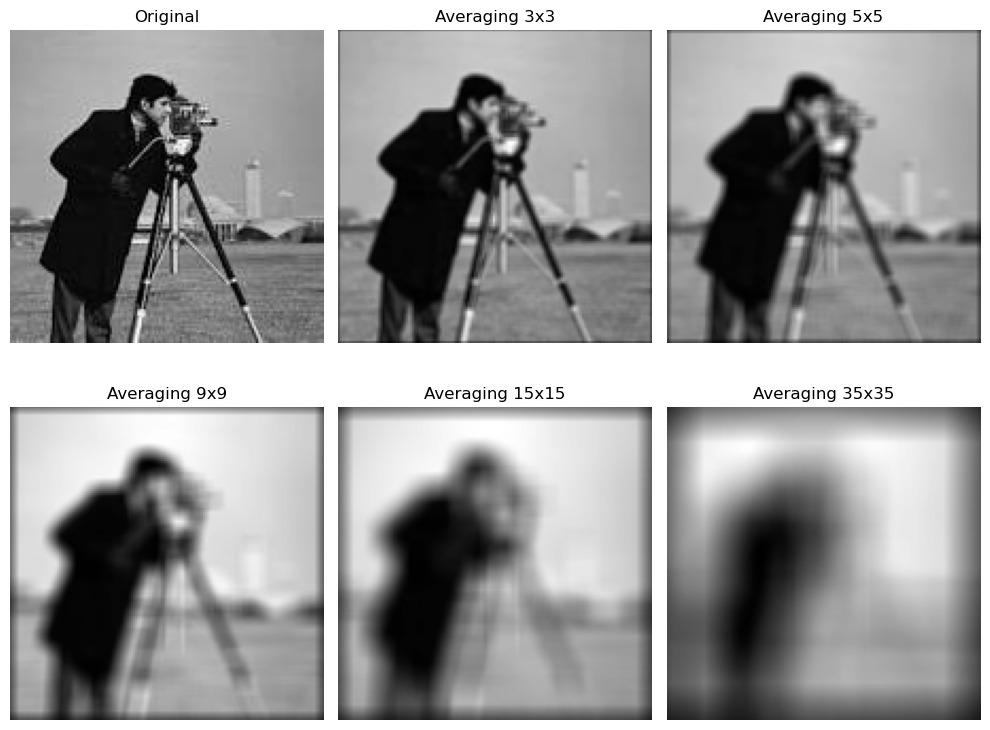

<Figure size 640x480 with 0 Axes>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_img(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Error: Unable to read image at {image_path}")
    return img
'''
def apply_avg_filter(image):
    kernel_sizes = [3, 5, 9, 15, 35]
    filtered_images = []

    for k in kernel_sizes:
        blurred = cv2.blur(image, (k, k))  
        filtered_images.append((blurred, k))

    return filtered_images
'''
def apply_avg_filter(image):
    kernel_sizes = [3, 5, 9, 15, 35]
    filtered_images = []

    for k in kernel_sizes:
        pad = k // 2
        padded_img = np.pad(image, pad, mode='constant', constant_values=0)
        filtered = np.zeros_like(image)

        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                region = padded_img[i:i+k, j:j+k]
                filtered[i, j] = np.mean(region)

        filtered_images.append((filtered.astype(np.uint8), k))

    return filtered_images

def plot_filterd_imgs(image, filterd_images):
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    for i, (img, k) in enumerate(filterd_images, start=2):
        plt.subplot(2, 3, i)
        plt.imshow(img, cmap='gray')
        plt.title(f"Averaging {k}x{k}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    plt.savefig("outimg_problem2.png")
    
def main():
    img_path = "../test_imgs/cameraman.jpg"
    img = read_img(img_path)

    filterd_img = apply_avg_filter(img)
    plot_filterd_imgs(img, filterd_img)


if __name__ == "__main__":
    main()